In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

In [4]:
import set_paths
import src.preprocesing_tools as pt
import src.eda_tools as et
from src.utils import get_subplt_dim

In [5]:
prep_data = pd.read_csv(r"..\data\preprocessed.csv")
#Preparamos una copia estandarizada de los datos para el análisis de correlación
stzd_data = (prep_data - prep_data.mean())/prep_data.std()
prep_data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,0.035490


In [6]:
prep_data.iloc[:, 1:]

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,0.023982
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,0.781588,...,0,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,0.029890
6815,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,0.781586,...,0,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,0.038284
6816,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,0.781546,...,0,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,0.097649
6817,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,0.781663,...,0,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,0.044009


In [7]:
#Buscamos features binarias
d = prep_data.iloc[:, 1:]
binary_features = d.columns[d.nunique() == 2]
for bf in binary_features:
    print(f"La variable: \"{bf}\" es binaria")

La variable: " Liability-Assets Flag" es binaria


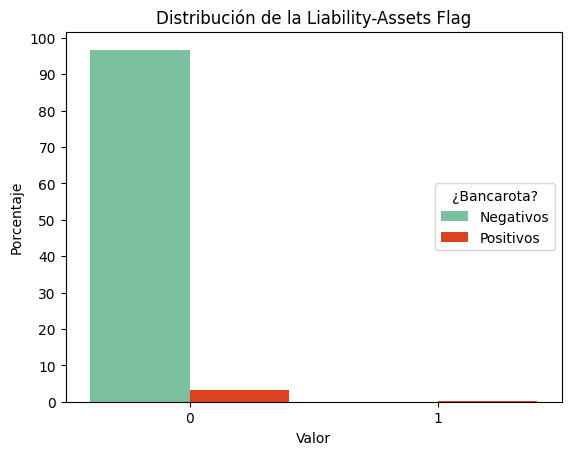

In [8]:
sns.countplot(data = prep_data, x = " Liability-Assets Flag", 
              stat = "percent", hue = "Bankrupt?", palette = ["#6fcb9f", "#fb2e01"])
plt.title("Distribución de la Liability-Assets Flag")
plt.xlabel("Valor")
plt.ylabel("Porcentaje")
plt.legend(title = "¿Bancarota?", loc = "right", labels = ["Negativos", "Positivos"])
plt.yticks(range(0, 101, 10))
plt.show()

## A primera inspección, notamos que la mayoría de las muestras toman 0 en esta variable. Precisamos en lo anterior:

In [9]:
laf_1s = prep_data[["Bankrupt?", " Liability-Assets Flag"]].where(prep_data[" Liability-Assets Flag"] == 1).dropna()
print(f"El porcentaje de empresas con \"Liability-Assets Flag\" = 1 es: {len(laf_1s)/len(prep_data)*100:.2f}%")


El porcentaje de empresas con "Liability-Assets Flag" = 1 es: 0.12%


## Dicha variable es prácticamente constante, por lo que no aporta información y la filtraremos

In [10]:
prep_data = prep_data.drop(" Liability-Assets Flag", axis = 1)
prep_data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Current Liability to Current Assets,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.118250,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.047775,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.025346,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.067250,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.047725,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,0.035490


## Se observa un importante desbalance en el target, contando con un ratio de 30 a 1 (30 negativos por cada positivo)

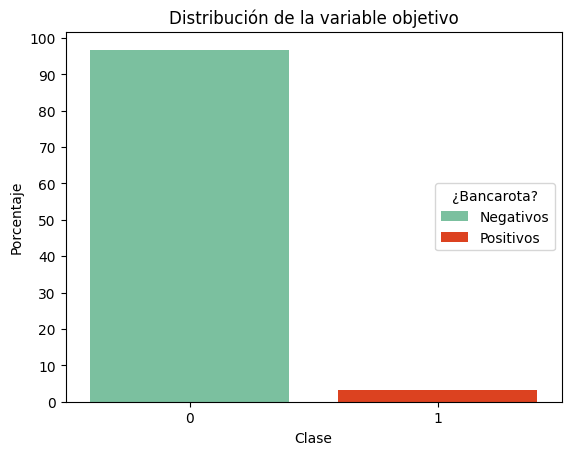

Ratio de positivos a negativos: 30:1


In [11]:
sns.countplot(data = prep_data, x = "Bankrupt?", 
              stat = "percent", hue = "Bankrupt?", palette = ["#6fcb9f", "#fb2e01"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.legend(title = "¿Bancarota?", loc = "right", labels = ["Negativos", "Positivos"])
plt.yticks(range(0, 101, 10))
plt.show()

n_positive = prep_data["Bankrupt?"].sum()
n_negative = len(prep_data) - n_positive
ratio = n_negative / n_positive
print(f"Ratio de positivos a negativos: {int(np.round(ratio))}:1")

## Calculamos la matriz de correlación (Pearson) en busca de posibles redundancias entre feautures

<Axes: title={'center': 'Coeficiente de correlación de Pearson entre features'}>

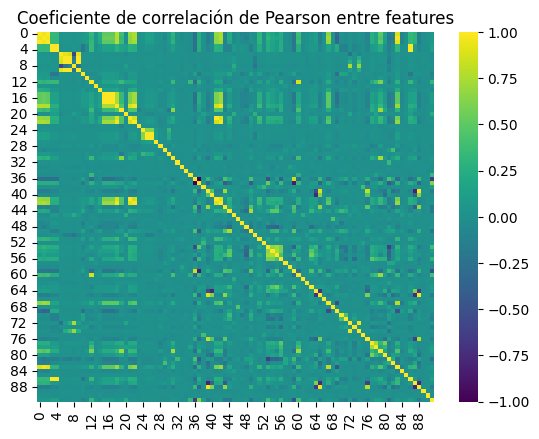

In [12]:
pcc_features_matrix = np.corrcoef(stzd_data.iloc[:, 1:].T.to_numpy())
plt.title("Coeficiente de correlación de Pearson entre features")
sns.heatmap(pcc_features_matrix, cmap = "viridis")

Text(0, 0.5, 'Conteo')

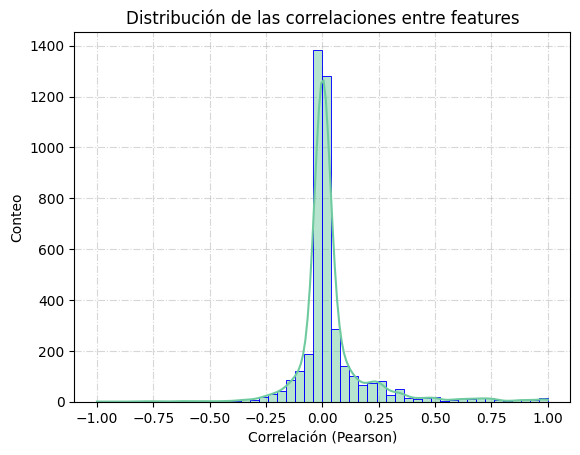

In [13]:
#No contamos las autocorrelaciones
ef_pcc_arr, ef_pcc_index = et.effective_correlations(pcc_features_matrix, diagonal = False, indices = True)
plt.title("Distribución de las correlaciones entre features")
plt.grid(linestyle = "dashdot", alpha = 0.5, zorder = 1)
sns.histplot(ef_pcc_arr, bins = 50,  stat = "count", zorder = 2, color = "#6fcb9f", edgecolor = "blue", kde = True)
plt.xlabel("Correlación (Pearson)")
plt.ylabel("Conteo")

## Si bien la distribución tiene una cola alargada a la derecha (más correlaciones positivas que negativas), la gran mayoría de correlaciones son menores a 0.5 en valor absoluto, por lo que no hay mucha redundancia.
## En cualquier caso, nos aseguramos de que no haya correlaciones perfectas

In [14]:
perfect_pcc_index = np.where(np.abs(ef_pcc_arr) == 1)[0]
print(f"Existen {len(perfect_pcc_index)} pares de features con correlación perfecta.")

Existen 1 pares de features con correlación perfecta.


In [15]:
p_row, p_column = ef_pcc_index[0][perfect_pcc_index][0] + 1 , ef_pcc_index[1][perfect_pcc_index][0] + 1 
prep_data.iloc[:, [0, p_row, p_column]]

,Bankrupt?,Debt ratio %,Net worth/Assets
0,1,0.207576,0.792424
1,1,0.171176,0.828824
2,1,0.207516,0.792484
3,1,0.151465,0.848535
4,1,0.106509,0.893491
...,...,...,...
6814,0,0.124618,0.875382
6815,0,0.099253,0.900747
6816,0,0.038939,0.961061
6817,0,0.086979,0.913021


Text(0, 0.5, ' Net worth/Assets')

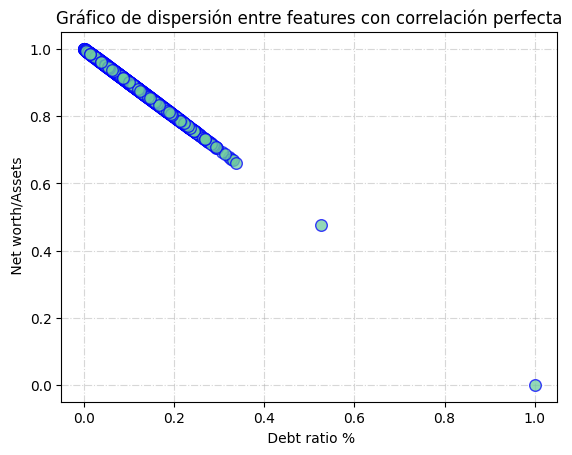

In [16]:
plt.title("Gráfico de dispersión entre features con correlación perfecta")
plt.scatter(prep_data.iloc[:, p_row], prep_data.iloc[:, p_column], 
            alpha = 0.75, color = "#6fcb9f", edgecolor = "blue", s = 70, zorder = 2)
plt.grid(linestyle = "dashdot", alpha = 0.5, zorder = 1)
plt.xlabel(prep_data.columns[p_row])
plt.ylabel(prep_data.columns[p_column])

## A modo de análisis complementario, se explora la matriz de correlación usando el Distance Correlation Coeficient (DCC)

In [17]:
dcc_features_matrix = et.dcc_matrix(stzd_data.iloc[:, 1:].T.to_numpy())
ef_dcc_arr, ef_dcc_index = et.effective_correlations(dcc_features_matrix, diagonal = False, indices = True)

<Axes: title={'center': 'Matriz de correlación PCC'}>

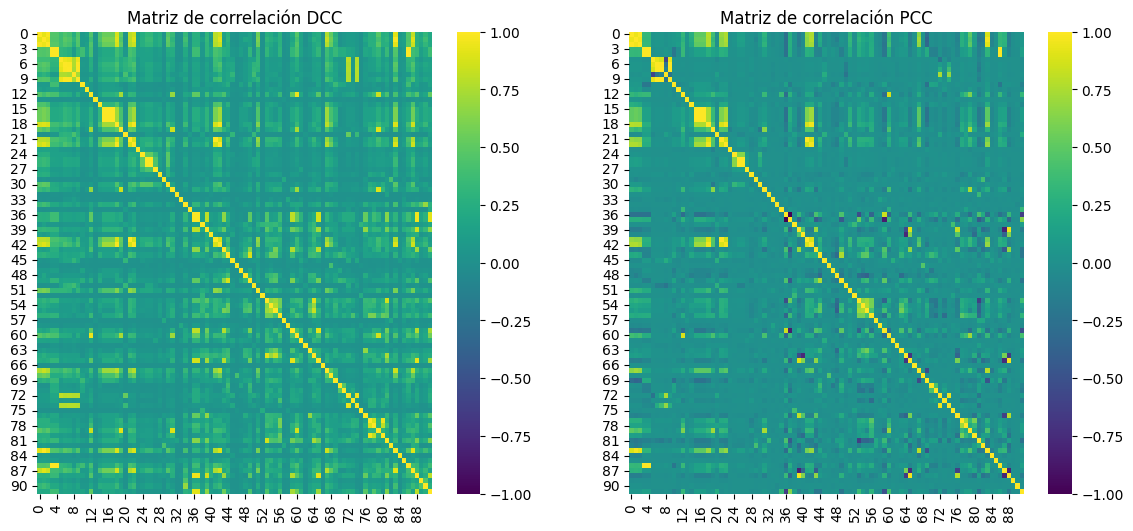

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title("Matriz de correlación DCC")
sns.heatmap(dcc_features_matrix, cmap = "viridis", vmin = -1, vmax = 1, ax = axes[0])
axes[1].set_title("Matriz de correlación PCC")
sns.heatmap(pcc_features_matrix, cmap = "viridis", ax = axes[1])

Text(0, 0.5, 'Conteo')

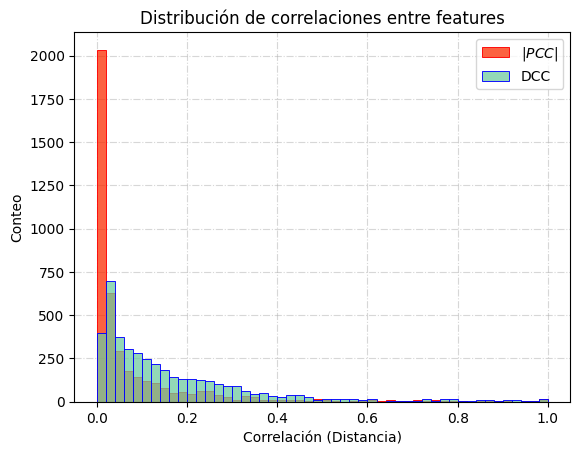

In [19]:
plt.title("Distribución de correlaciones entre features")
plt.grid(linestyle = "dashdot", alpha = 0.5, zorder = 1)
sns.histplot(np.abs(ef_pcc_arr), bins = 50,  stat = "count", zorder = 2, 
             color = "#fb2e01", edgecolor = "red", label = r"$|PCC|$")
sns.histplot(ef_dcc_arr, bins = 50,  stat = "count", zorder = 2, 
             color = "#6fcb9f", edgecolor = "blue", label = "DCC")

plt.legend(title = "", loc = "upper right")
plt.xlabel("Correlación (Distancia)")
plt.ylabel("Conteo")

## Si bien el conteo de DCC's positivos es mayor respecto a tomar el valor absoluto de PCC (lo que indica estructura no lineal de dependencia entre algunas features), la mayoría de correlaciones de distancia son bajas, por lo que las features son casi independientes

#### Filtramos las features con |PCC| > 0.99

Existen 20 pares de features con |PCC| >= 0.95.


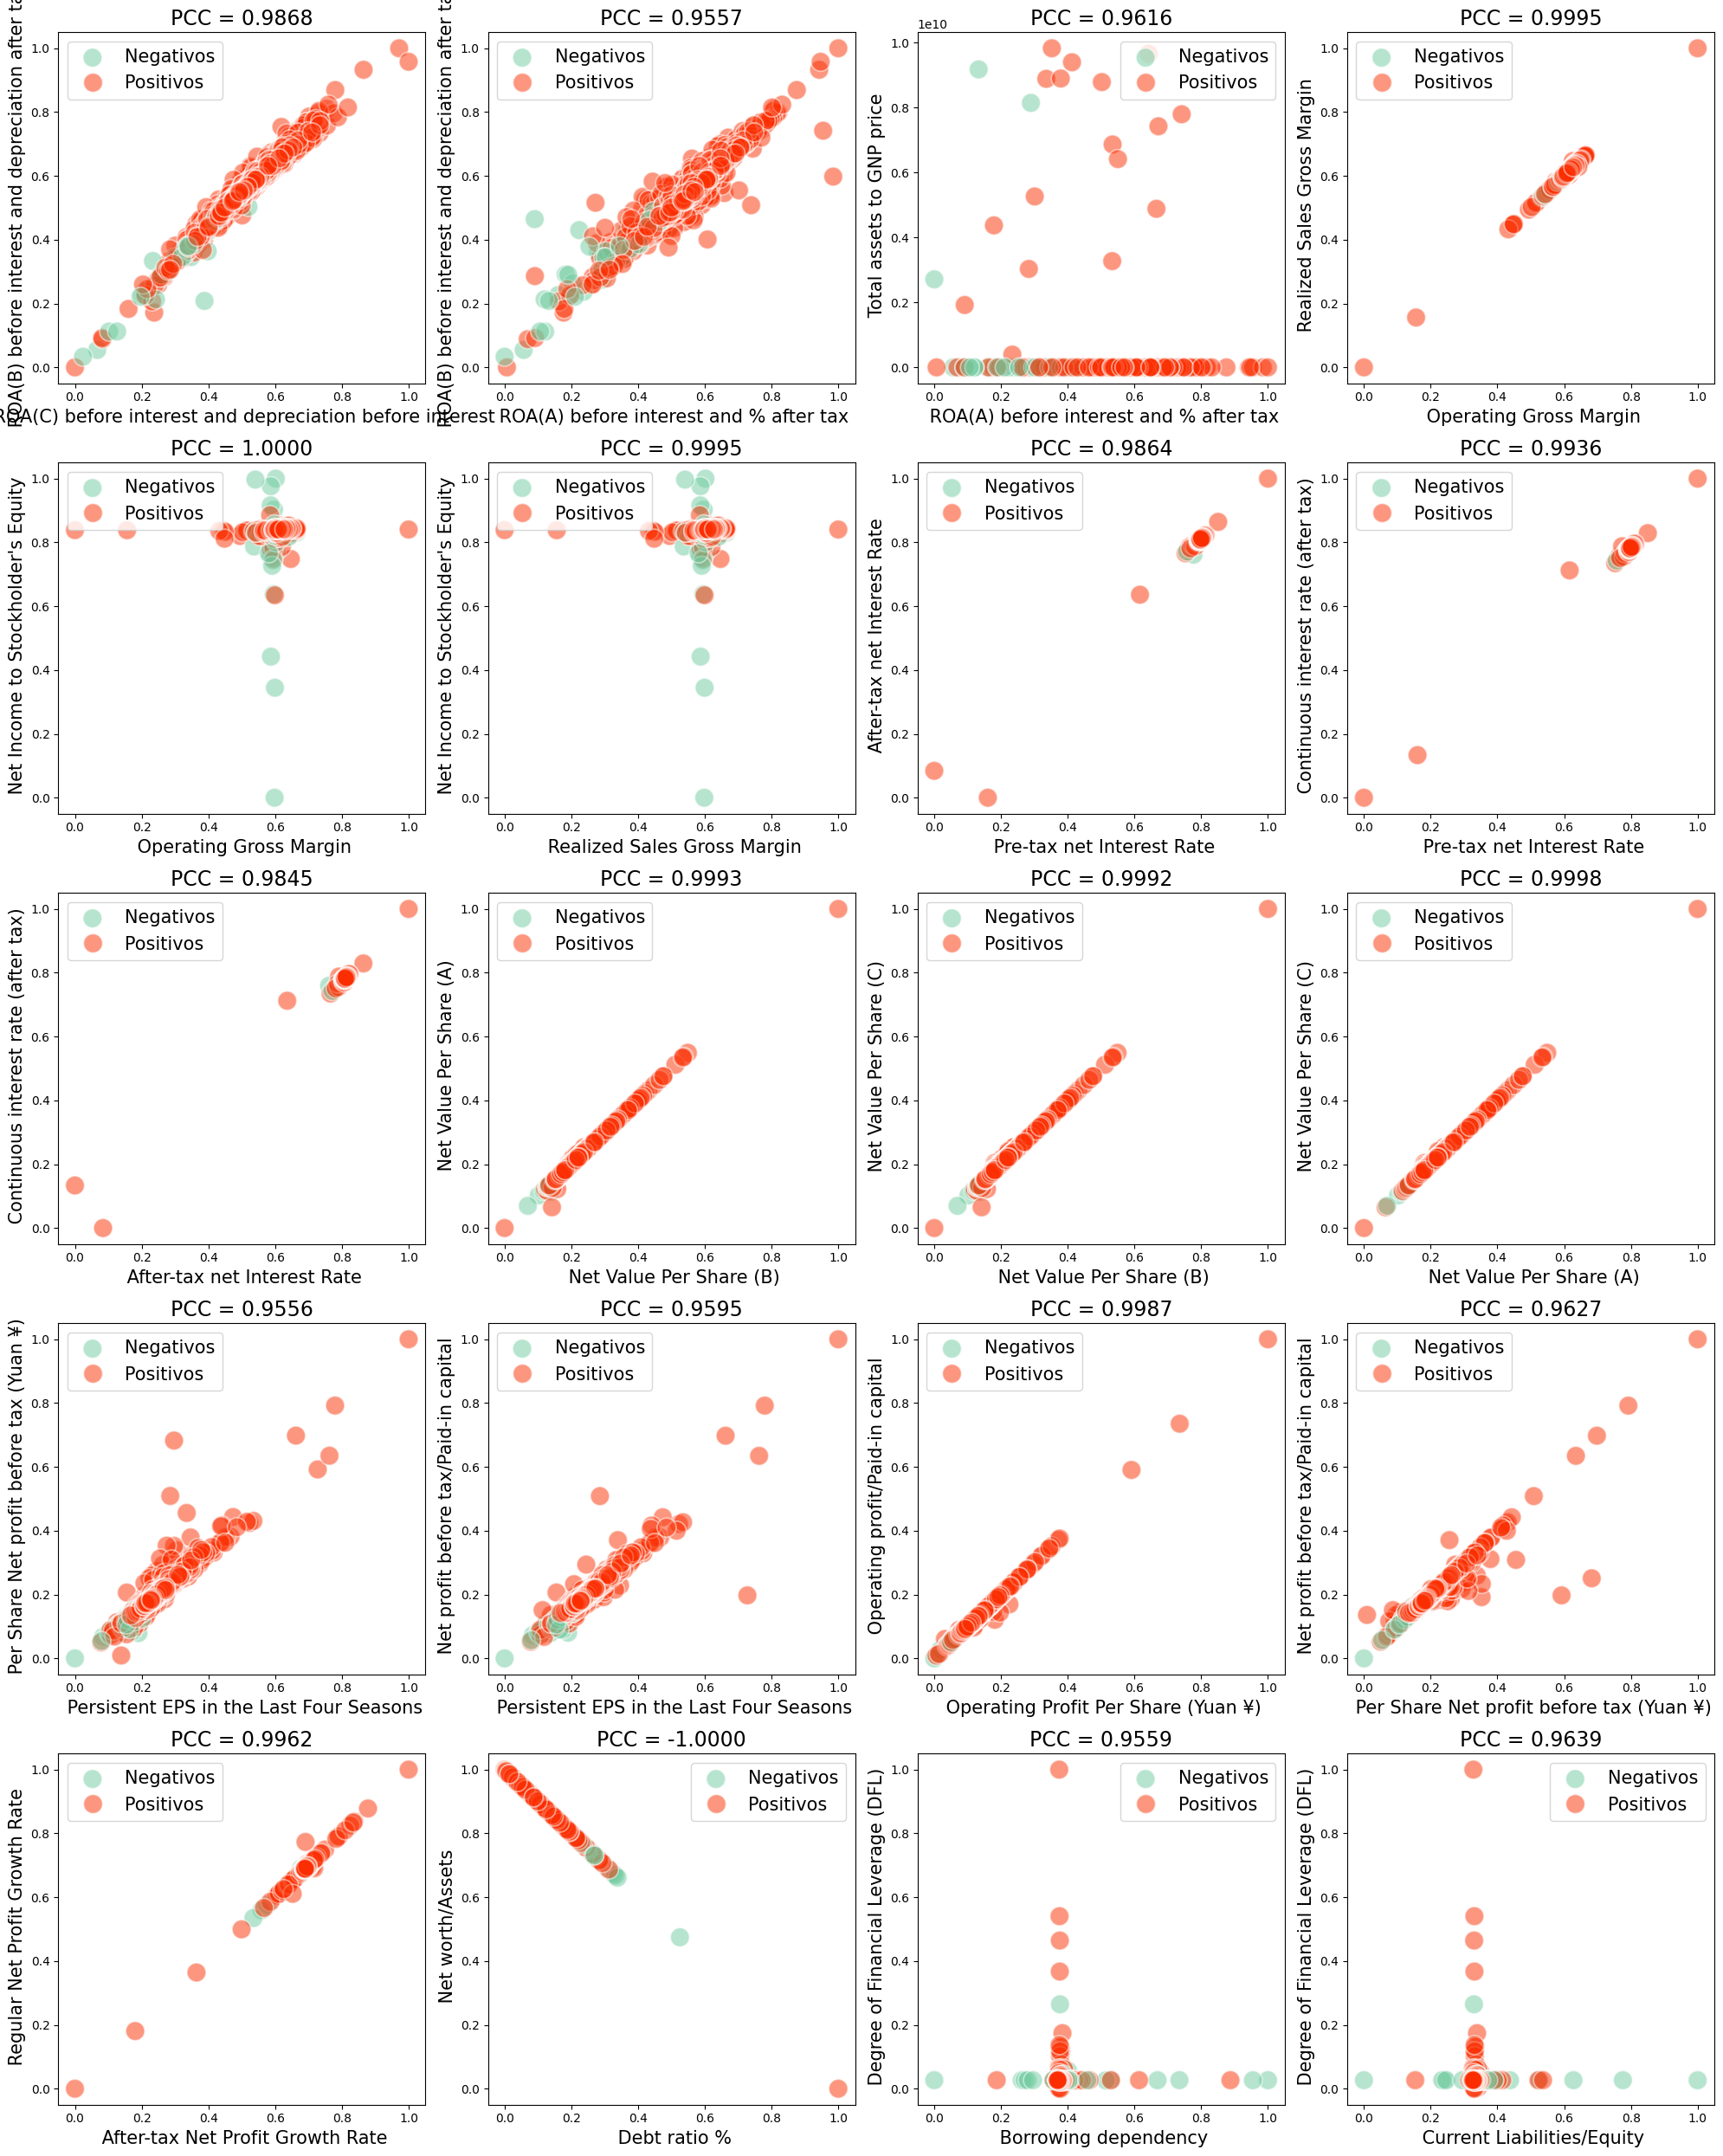

In [20]:
pcc_treshold = 0.95
ex_pcc_index = np.where(np.abs(ef_pcc_arr) >= pcc_treshold)[0]
print(rf"Existen {len(ex_pcc_index)} pares de features con |PCC| >= {pcc_treshold}.")

rows, columns = get_subplt_dim(len(ex_pcc_index))

fig, axes = plt.subplots(rows, columns, figsize=(5*columns, 5*rows))
axes = axes.flatten()

for i in range(len(axes)):
    #f stands for feature

    index = ex_pcc_index[i]
    f_1_index = ef_pcc_index[0][index] + 1
    f_2_index = ef_pcc_index[1][index] + 1
    f_1 = prep_data.iloc[:, f_1_index]
    f_2 = prep_data.iloc[:, f_2_index]

    axes[i].set_title(f"PCC = {ef_pcc_arr[index]:.4f}", fontsize = 17)
    #plt.grid(linestyle = "dashdot", alpha = 0.5, zorder = 1)
    sns.scatterplot(data = prep_data, x=f_1, y=f_2, ax=axes[i], hue ="Bankrupt?", s=250,
                    hue_order= [0, 1],  palette = ["#fb2e01", "#6fcb9f"], alpha = 0.5)#, zorder = 2)
    axes[i].set_xlabel(prep_data.columns[f_1_index], fontsize = 15)
    axes[i].set_ylabel(prep_data.columns[f_2_index], fontsize = 15)
    axes[i].legend(loc = "best", labels = ["Negativos", "Positivos"], fontsize = 15)
    plt.tight_layout()


In [21]:
#Eliminamos un feature altamente correlacionado por par
to_pop = ef_pcc_index[0][ex_pcc_index]
to_pop = list(set([i+1 for i in to_pop]))
to_pop = prep_data.columns[to_pop]
prep_data_2 = prep_data.drop(columns = to_pop, inplace = False)
stzd_data_2 = stzd_data.drop(columns = to_pop, inplace = False)

# A continuación se exhiben las distribuciones de features por clase

Features restantes: 76


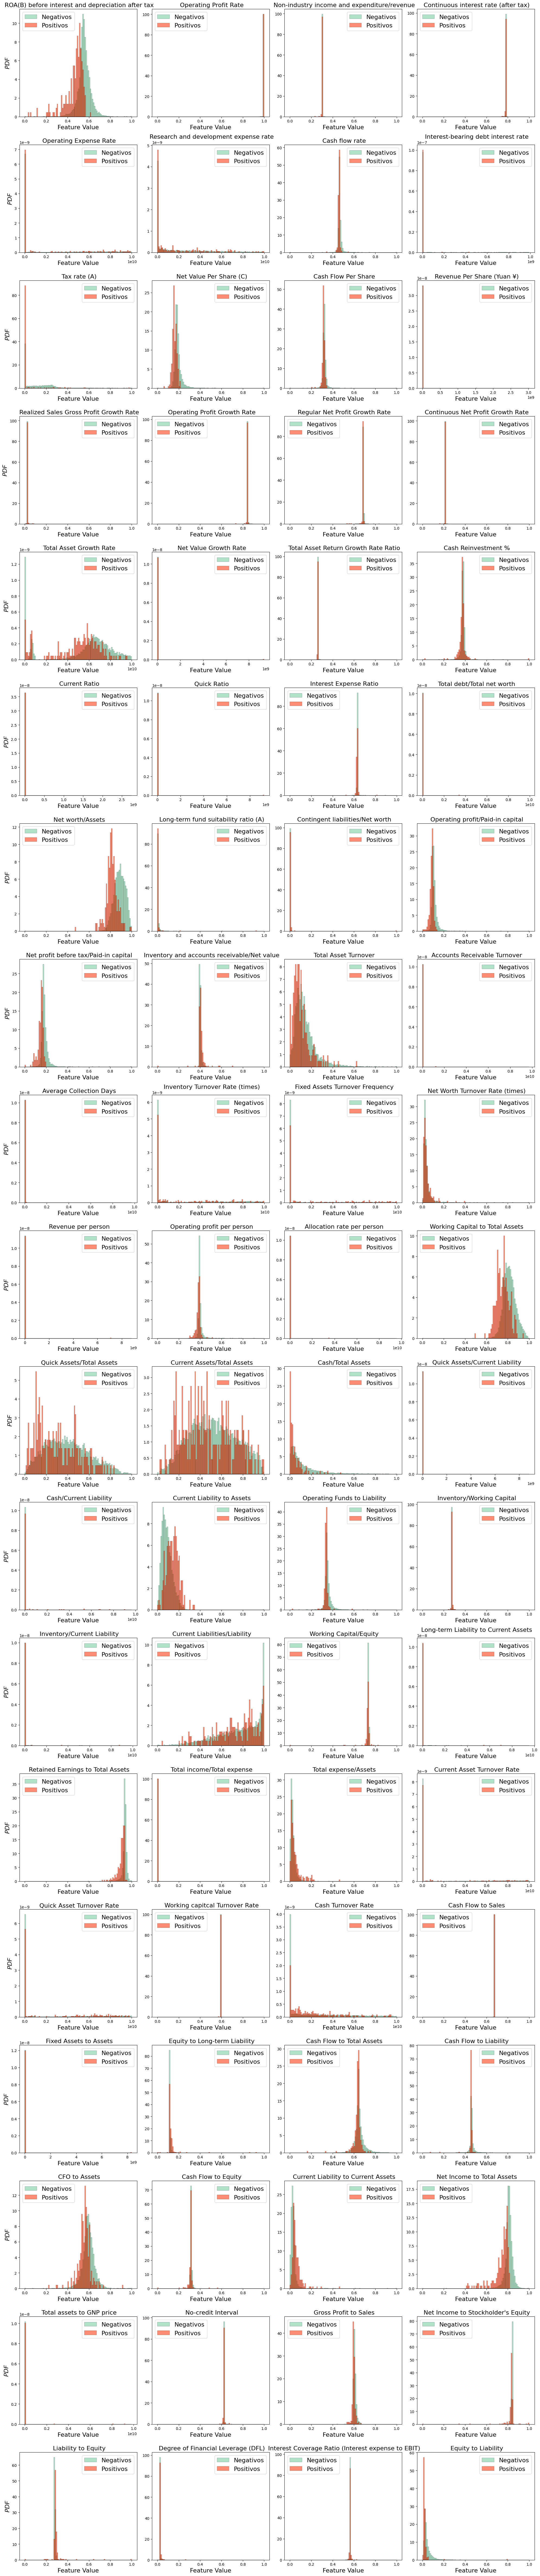

In [23]:
rows, columns = get_subplt_dim(prep_data_2.shape[1] - 1)
fig, axes = plt.subplots(rows, columns, figsize=(5*columns, 5*rows))
axes = axes.flatten()
stat_estad = ["density", r"$PDF$"]
for i in range(len(axes)):
    #PLOT
    sns.histplot(data = prep_data_2, x = prep_data_2.iloc[:, i + 1], bins = 100, ax = axes[i] 
                 , hue_order=[1, 0], stat = stat_estad[0], hue = prep_data["Bankrupt?"], 
                 palette = ["#fb2e01", "#6fcb9f"], alpha = 0.55, common_norm = False)
    #LEYTENDAS Y ETIQUETAS
    axes[i].legend(loc = "best", labels = ["Negativos", "Positivos"], fontsize = 16)
    axes[i].set_title(f"{prep_data_2.columns[i + 1]}", fontsize = 16)
    y_label = stat_estad[1] if i%columns == 0 else ""
    axes[i].set_xlabel("Feature Value", fontsize = 16)
    axes[i].set_ylabel(y_label, fontsize = 16)
    
plt.tight_layout()
print(f"Features restantes: {prep_data_2.shape[1] - 1}")

## Muchas variables parecen tener una distribución tipo delta, por lo que no filtraremos basados en baja varianza, con 76 features restantes, damos por conluido el feature filtering inicial.

In [24]:
prep_data_2.to_csv(r"..\data\clean_.csv", index = False)